In [28]:
#Load modules
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [29]:
#Step 1
#pre-process the data
df = pd.read_csv("marketing_campaign.csv")

#select features
y= df['Response']
X = df.drop(['Response','ID'],axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

In [30]:
#Step 2
rf = RandomForestClassifier(random_state=69) #Define the model
#Define possible hyperparameters
n_estimators = np.arange(start=10, stop=250, step=10) #number of trees, it will try 10, 20, 30 etc
max_depth = np.arange(start=10,stop=250,step=10)
min_samples_split = np.arange(start=10,stop=30,step=1)
max_features = [None,'sqrt','log2']

#Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'max_features': max_features}

# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, 
                               param_distributions = random_grid, 
                               n_iter = 100, #number of combination in the grid to try
                               cv = 5,#number of folds
                               random_state=69) #set random seed
rf_random.fit(X,y)# Fit the random search model

rf_random.best_params_ #reveal the best hyperparameters

{'n_estimators': 220,
 'min_samples_split': 14,
 'max_features': None,
 'max_depth': 140}

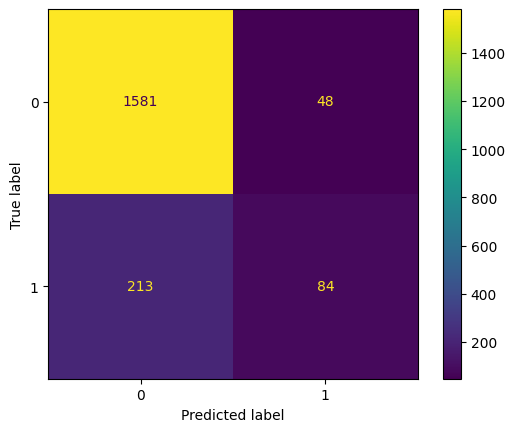

Accuracy: 0.8644859813084113


In [31]:
#Step 2
#Create optimal prediction and test its accuracy
rf = RandomForestClassifier(n_estimators=220, 
                            min_samples_split=14,
                            max_features=None,
                            max_depth=140,
                            random_state=69)

y_pred = cross_val_predict(rf, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

accuracy = (cm.diagonal().sum()) / cm.sum() #calculate accuracy
print("Accuracy:",accuracy) #print accuracy

In [38]:
#Step 3

#fit the final model
rf = RandomForestClassifier(n_estimators=150, 
                            min_samples_split=10,
                            max_features=None,
                            max_depth=210,
                            random_state=69)
rf.fit(X,y)

#load the new data
new_customers = pd.read_csv('new_customers.csv') #load the data
new_customers = new_customers.drop('ID',axis=1) #remove the ID variable
new_customers = pd.get_dummies(new_customers, drop_first=True) #create dummies

#Normalize the data
columns = new_customers.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
new_customers = scaler.fit_transform(new_customers) #scale the data
new_customers = pd.DataFrame(new_customers,columns=columns) #turn back into a dataframe

predictions = rf.predict(new_customers) #make the predictions

percentage = np.mean(predictions)*100 #the average is functionally the same as the percentage here

print(f"Percentage of customers that are predicted to respond: {percentage:.1f}")

Percentage of customers that are predicted to respond: 23.6
